### Business challenge/requirement
SFO Public Department - referred to as SFO has captured all the salary data of its employees from the year 2011-2014. Now we are in the year 2015 and the organization is facing a financial crisis. As the first step HR wants to rationalize employee costs to save the payroll budget. You have to do data manipulation and analysis on the salary data to answer specific questions for cost savings.
### Key issues
Cost can be saved by figuring out the key pockets of high salaries
### Considerations
NONE
### Data volume
- Approx 150K records across files
### additional information
- NA
### Business benefits
Save at least 10% of employee costs by identifying and letting them go

### Approach to Solve
You have to use the fundamentals of Pandas covered in module 6 and answer the
following 5 Questions

1. Compute how much total salary cost has increased from the year 2011 to 2014
2. Which Job Title in the Year 2014 has the highest mean salary?
3. How much money could have been saved in the Year 2014 by stopping OverTimePay?
4. Which are the top 5 common jobs in the Year 2014 and how much do they cost SFO?
5. Who was the top earning employee across all the years?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms.bipartite.basic import color
from panel import widget
from sympy.abc import alpha

plt.style.use('default')

In [3]:
data = pd.read_csv('./files/Salaries.csv', low_memory=False, na_values=[np.nan,None,''])
data

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148643,148646,Carolyn A Wilson,Human Services Technician,0.00,0.00,0.00,0.0,0.00,0.00,2014,NaN,San Francisco,PT
148644,148648,Joann Anderson,Communications Dispatcher 2,0.00,0.00,0.00,0.0,0.00,0.00,2014,NaN,San Francisco,PT
148645,148649,Leon Walker,Custodian,0.00,0.00,0.00,0.0,0.00,0.00,2014,NaN,San Francisco,PT
148646,148650,Roy I Tillery,Custodian,0.00,0.00,0.00,0.0,0.00,0.00,2014,NaN,San Francisco,PT


In [4]:
#data cleaning
data.BasePay = data.BasePay.replace(np.nan,0)
data.Benefits = data.Benefits.replace(np.nan,0)
data['Status'] = data.Status.fillna('Unknown')
data.drop('Notes',axis=1,inplace=True)

data['JobTitle'] = data['JobTitle'].str.split(',')
data = data.explode('JobTitle')
data['JobTitle'] = data['JobTitle'].str.strip()

# Rename any title containing "MtBdComm|Mtg|Mg" to "Board/Commission Member"
data.loc[data['JobTitle'].str.contains('Grp|Member|M\$|Mtg', case=False, na=False), 'JobTitle'] = 'Board/Commission Member'

#data.info()

In [5]:
data.isnull().sum()

Id                  0
EmployeeName        0
JobTitle            0
BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
Year                0
Agency              0
Status              0
dtype: int64

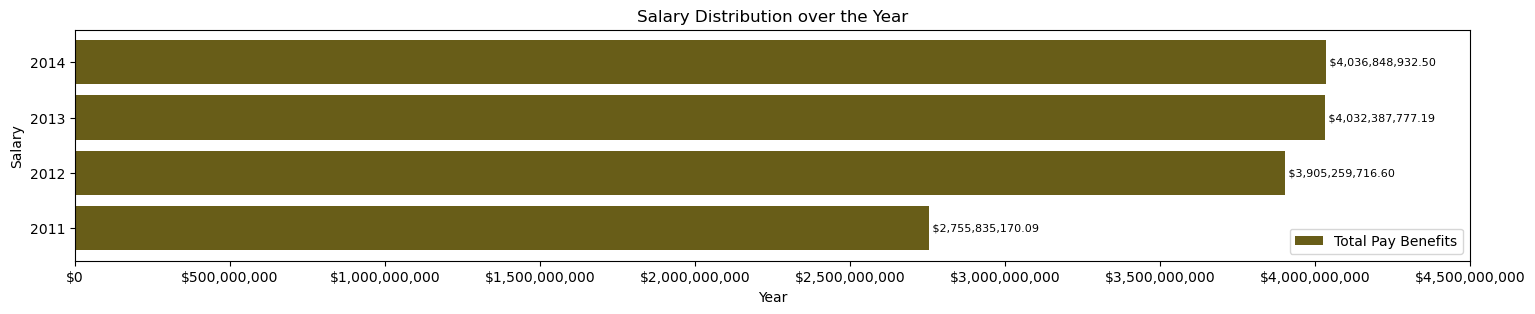

Total Salary Cost : $1,281,013,762.41


In [65]:
# 1. Compute how much total salary cost has increased from the year 2011 to 2014

salary_by_year_df = data.groupby("Year",as_index=False)['TotalPayBenefits'].sum()

plt.figure(figsize = (18,3))
h_bars = plt.barh(salary_by_year_df['Year'],salary_by_year_df['TotalPayBenefits'],label = 'TotalPayBenefit', color = '#685d18')
plt.title('Salary Distribution over the Year')
plt.xlabel('Year')
plt.ylabel('Salary')
plt.ylabel('Salary')
plt.ticklabel_format(axis='x',style='plain')
plt.legend(['Total Pay Benefits'])
plt.xticks(plt.gca().get_xticks(), [f"${x:,.0f}" for x in plt.gca().get_xticks()])
for bar in h_bars:
    plt.text(
        x= bar.get_width(),
        y= bar.get_y()+bar.get_height()/2,
        s=f" ${bar.get_width():,.2f}",
        ha='left',
        va='center',
        fontsize='8',
    )
plt.show()

total_salary_cost = (salary_by_year_df['TotalPayBenefits'].iloc[np.where(salary_by_year_df['Year']==2014)].sum() - salary_by_year_df['TotalPayBenefits'].iloc[np.where(salary_by_year_df['Year']==2011)].sum())
print(f"Total Salary Cost : ${total_salary_cost:,.2f}")

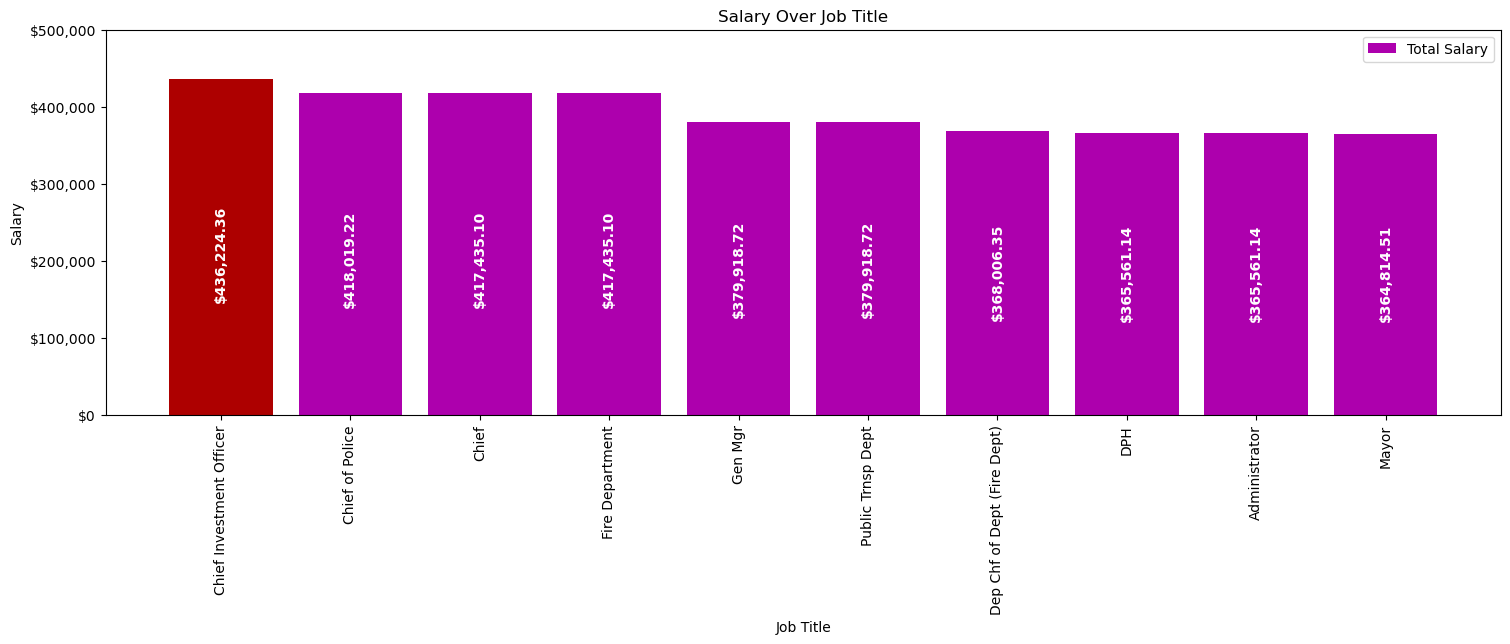

In [64]:
# 2. Which Job Title in the Year 2014 has the highest mean salary?
emp_2014_df = data[data['Year']==2014].groupby('JobTitle',as_index=False)['TotalPayBenefits'].mean().sort_values(by='TotalPayBenefits',ascending=False).head(10)

plt.figure(figsize = (18,5))
sal_bars = plt.bar(emp_2014_df['JobTitle'],emp_2014_df['TotalPayBenefits'],label = 'TotalPayBenefit', color = '#ad00ad')
plt.bar(emp_2014_df.iloc[np.where(emp_2014_df.TotalPayBenefits == emp_2014_df['TotalPayBenefits'].max())]['JobTitle'],emp_2014_df.iloc[np.where(emp_2014_df.TotalPayBenefits == emp_2014_df['TotalPayBenefits'].max())]['TotalPayBenefits'],color='#ad0000')
plt.title('Salary Over Job Title')
plt.xlabel('Job Title')
plt.ylabel('Salary')
plt.xticks(rotation=90)
plt.ticklabel_format(axis='y',style='plain')
plt.yticks(plt.gca().get_yticks(), [f"${x:,.0f}" for x in plt.gca().get_yticks()])
plt.legend(['Total Salary'])
for bar in sal_bars:
    plt.text(x=(bar.get_x()+bar.get_width()/2),y=bar.get_height()/3,s=f"${bar.get_height():,.2f}",ha='center',va='bottom',color='white',rotation=90, fontweight='bold')
plt.show()

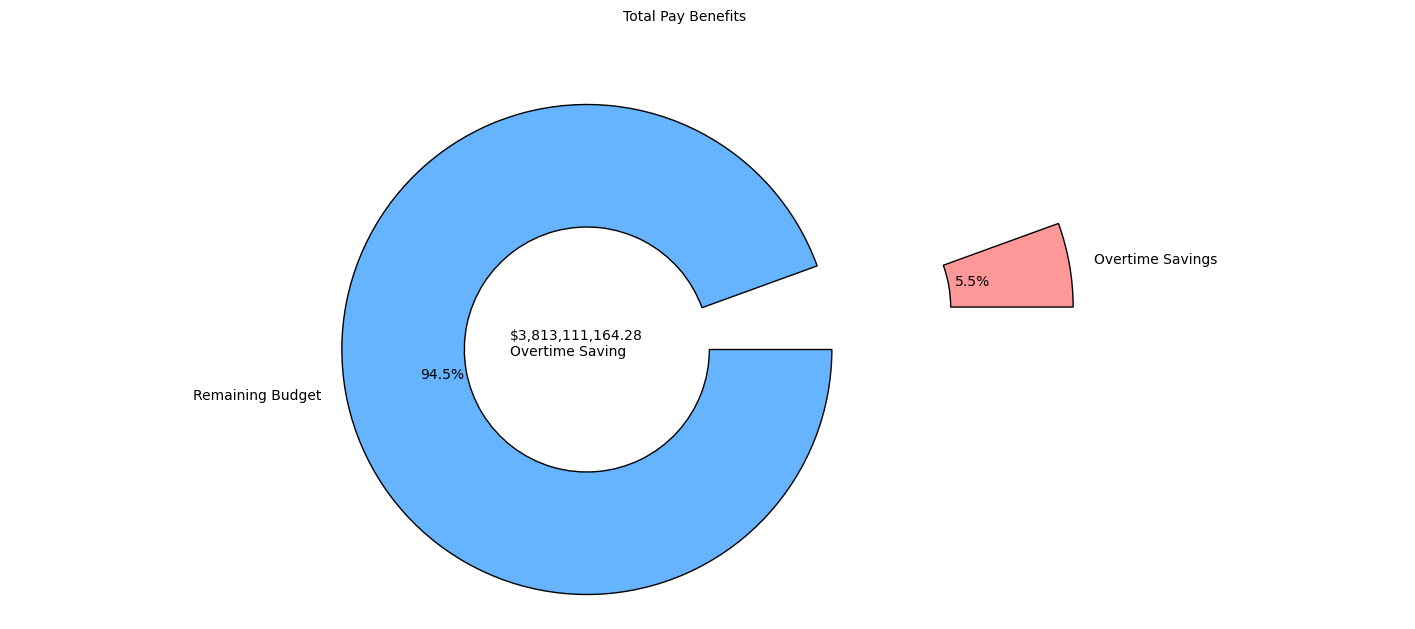

In [61]:
# 3. How much money could have been saved in the Year 2014 by stopping OverTimePay?
data_2014_df = data[data.Year == 2014].copy()
overtime_pay = data_2014_df['OvertimePay'].sum()
total_pay = data_2014_df['TotalPayBenefits'].sum()
other_cost = total_pay - overtime_pay

plt.figure(figsize = (18,7))
plt.pie([overtime_pay,other_cost],labels=['Overtime Savings', 'Remaining Budget'],autopct='%1.1f%%',explode=[0,1],wedgeprops=dict(width=0.5,edgecolor='black'),colors=['#ff9999','#66b3ff'])
plt.suptitle("Total Pay Benefits",fontsize=10)
plt.text(-1.30,-0.20,f'${other_cost:,.2f}\nOvertime Saving',color='black')
plt.axis('equal')
plt.show()

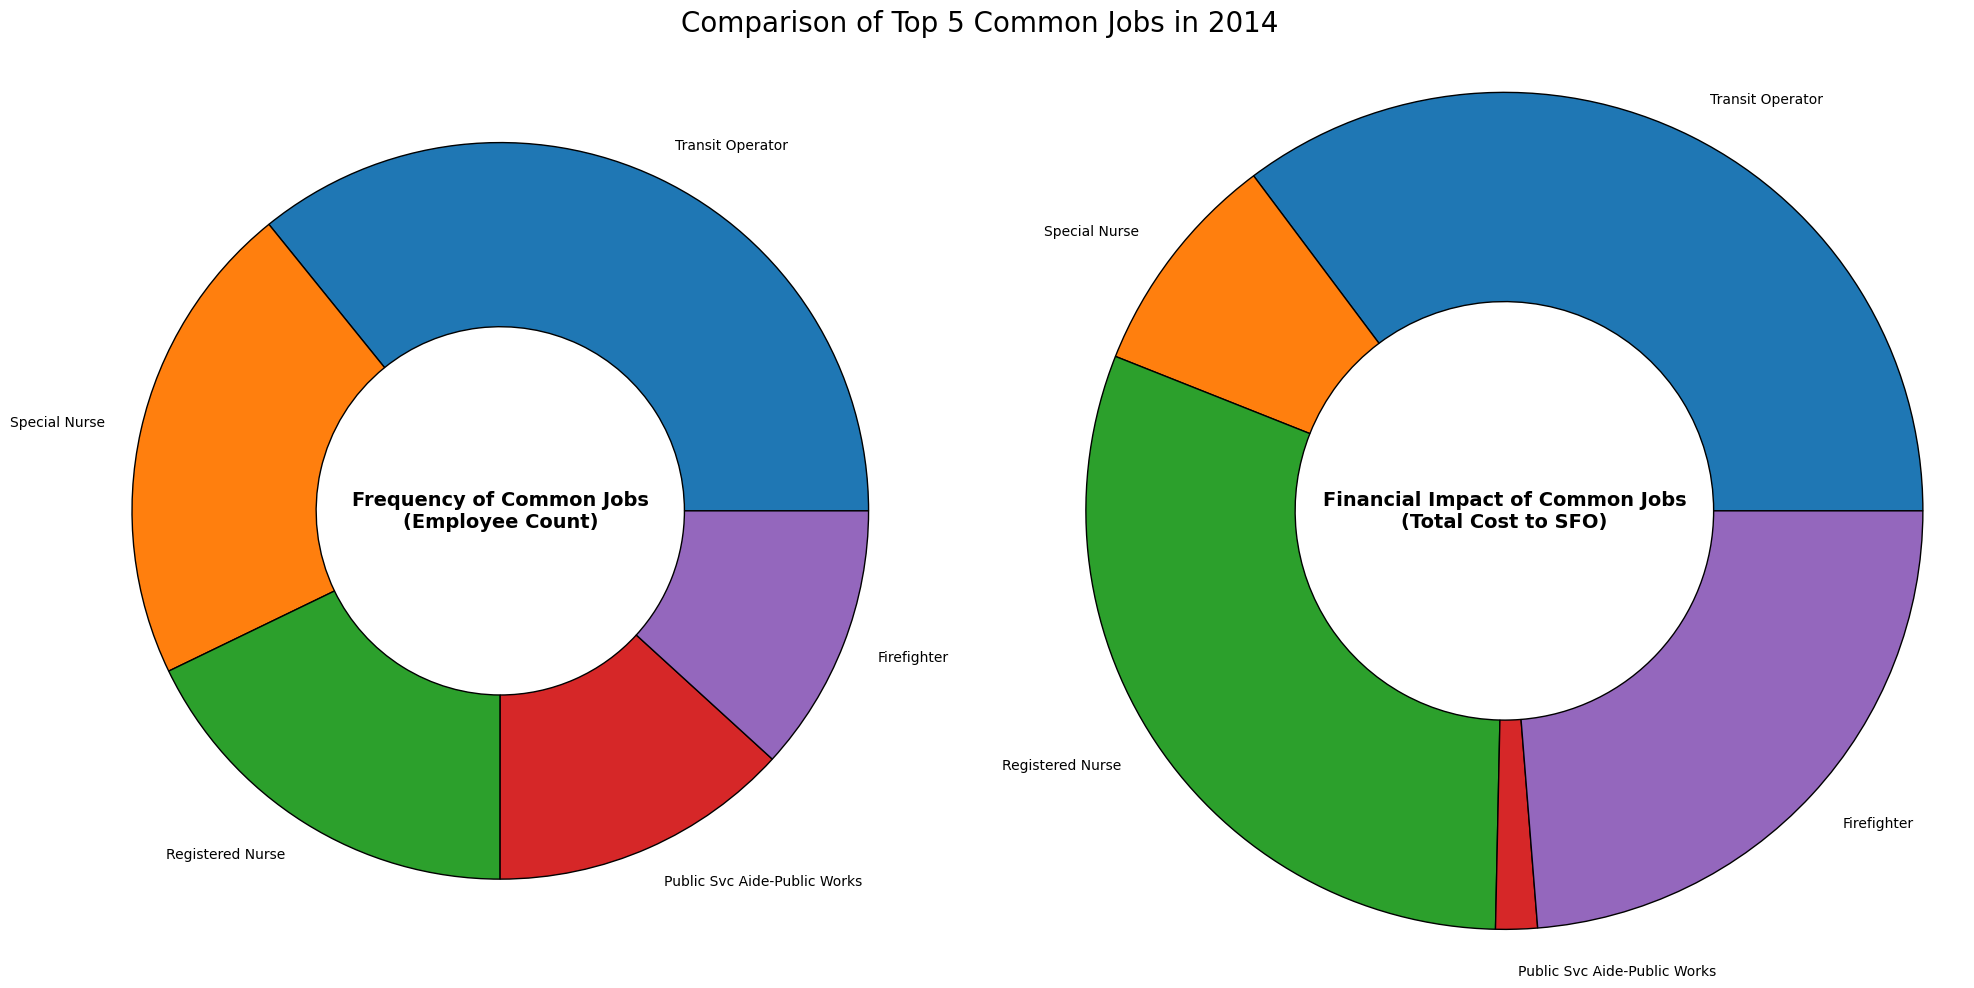

In [9]:
# 4. Which are the top 5 common jobs in the Year 2014 and how much do they cost SFO?
top_5_jobs_df = data_2014_df.groupby('JobTitle',as_index=False)['TotalPayBenefits'].agg(['count','sum']).sort_values(by='count',ascending=False).head(5)
top_5_jobs_df.columns = ['Job','Employee_Count', 'Total_Cost_to_SFO']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.pie(top_5_jobs_df['Employee_Count'],labels=top_5_jobs_df['Job'],wedgeprops=dict(width=0.5,edgecolor='black'))
ax1.text(0,0,'Frequency of Common Jobs\n(Employee Count)', fontsize=14, fontweight='bold',va='center',ha='center')


ax2.pie(top_5_jobs_df['Total_Cost_to_SFO'],labels=top_5_jobs_df['Job'],wedgeprops=dict(width=0.5,edgecolor='black'))
ax2.text(0,0,'Financial Impact of Common Jobs\n(Total Cost to SFO)', fontsize=14, fontweight='bold',va='center',ha='center')

plt.suptitle('Comparison of Top 5 Common Jobs in 2014', fontsize=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

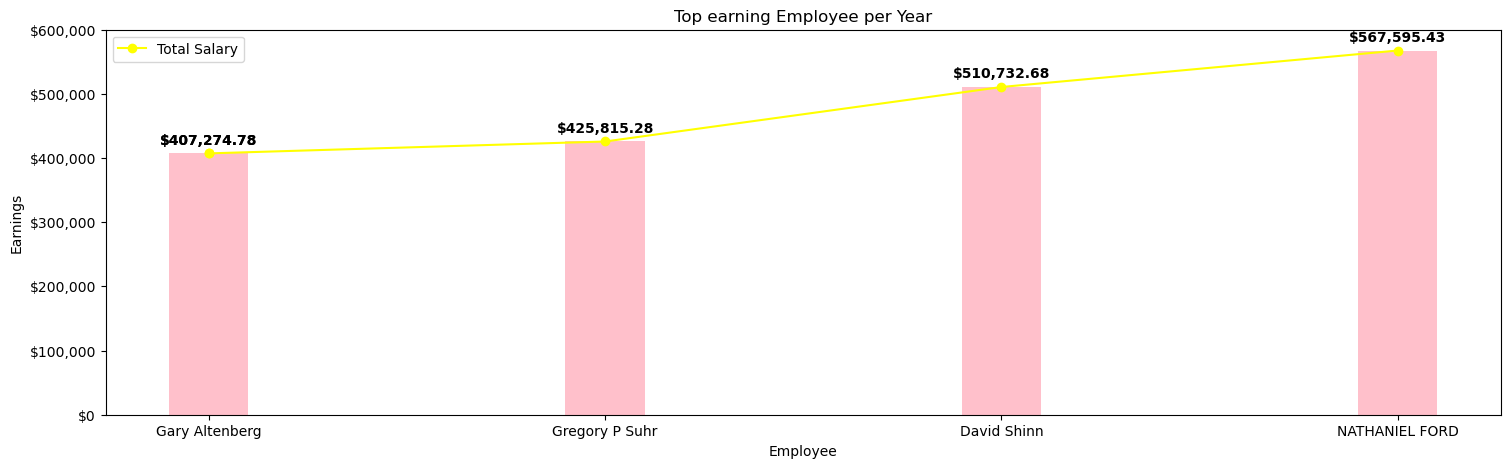

In [26]:
# 5. Who was the top earning employee across all the years?

top_earning_index = data.groupby('Year')['TotalPayBenefits'].idxmax()
top_earning_df = data.loc[top_earning_index,['Year','EmployeeName','TotalPayBenefits']].sort_values(by='TotalPayBenefits',ascending=True)

plt.figure(figsize = (18,5))
bars = plt.bar(top_earning_df['EmployeeName'],top_earning_df['TotalPayBenefits'],label = 'Total Pay Benefit', color = 'pink',width=0.2)
plt.plot(top_earning_df['EmployeeName'],top_earning_df['TotalPayBenefits'],label = 'Total Pay Benefit', color = 'yellow',marker='o')
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, # X position: Center of the bar
        yval+10000,                            # Y position: Top of the bar
        f'${yval:,.2f}',                 # The label: Formatted pay
        va='bottom',                     # Vertical alignment: above the coordinate
        ha='center',                     # Horizontal alignment: centered
        fontsize=10,
        fontweight='bold'
    )
plt.title('Top earning Employee per Year')
plt.xlabel('Employee')
plt.ylabel('Earnings')
plt.ticklabel_format(axis='y',style='plain')
plt.yticks(plt.gca().get_yticks(), [f"${x:,.0f}" for x in plt.gca().get_yticks()])
plt.legend(['Total Salary'])
plt.show()

### Enhancements for code
You can try these enhancements in code
1. Which are the last 5 common jobs in the Year 2014 and how much do they cost
SFO?
2. In year 201 OverTimePay was what percentage of TotalPayBenefits
3. Which Job Title in the Year 2014 has the lowest mean salary?

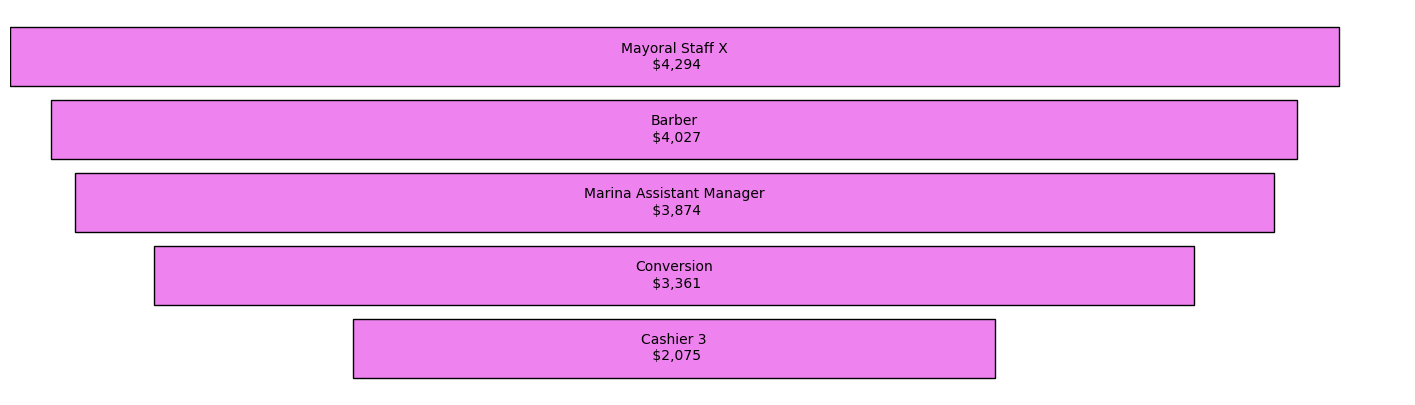

In [11]:

# 1. Which are the last 5 common jobs in the Year 2014 and how much do they cost SFO?

last_5_jobs = data_2014_df.groupby('JobTitle',as_index=False)['TotalPayBenefits'].agg(['count','sum']).sort_values(by='sum',ascending=True).head(5).reset_index()

plt.figure(figsize = (18,5))
bar_h = plt.barh(last_5_jobs['JobTitle'],last_5_jobs['sum'],color='violet',left=-last_5_jobs['sum']/2,edgecolor='black')

for i, (name, val) in enumerate(zip(last_5_jobs['JobTitle'], last_5_jobs['sum'])):
    plt.text(0, i, f"{name}\n ${val:,.0f}", ha='center', va='center', color='black', fontsize=10)

plt.axis('off')
plt.show()

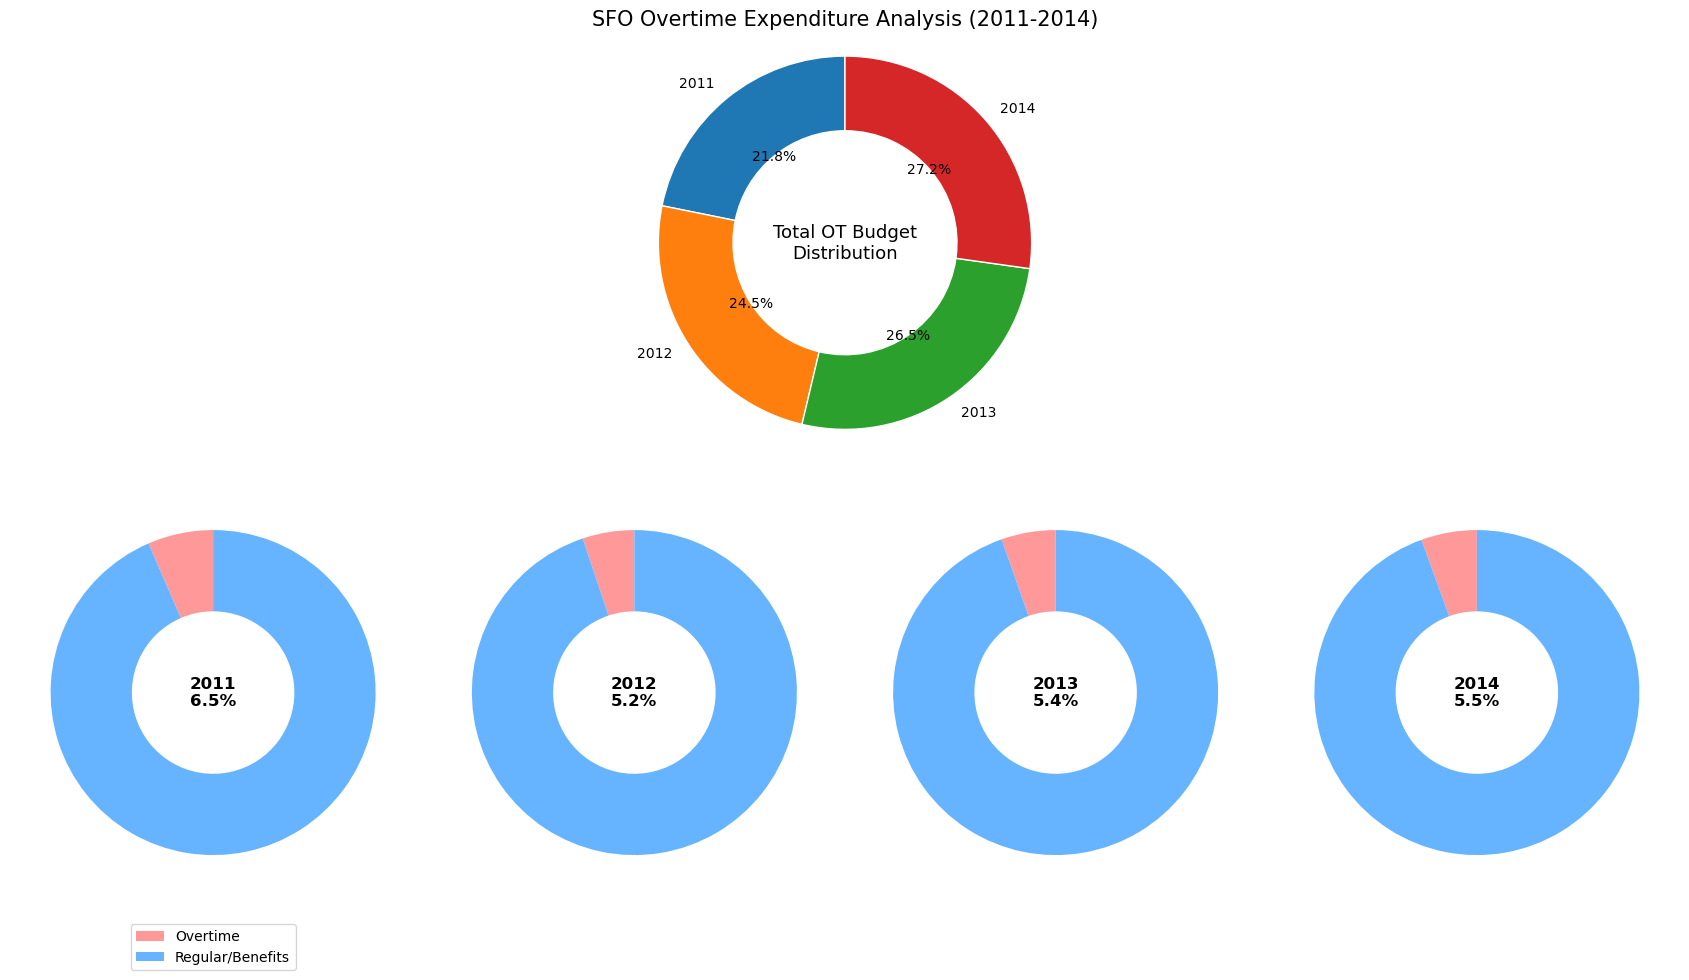

In [67]:
# 2. In year 201 OverTimePay was what percentage of TotalPayBenefits

yearly_totals = data.groupby('Year')[['OvertimePay', 'TotalPayBenefits']].sum()
yearly_totals['OT_Rate'] = (yearly_totals['OvertimePay'] / yearly_totals['TotalPayBenefits']) * 100
yearly_totals = yearly_totals.reset_index()

fig = plt.figure(figsize=(17, 10))
gs = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(gs[0, :])
ax1.pie(yearly_totals['OvertimePay'], labels=yearly_totals['Year'],wedgeprops=dict(width=0.4, edgecolor='white'), autopct='%.1f%%', startangle=90)
ax1.text(0, 0, 'Total OT Budget\nDistribution', va='center', ha='center', fontsize=13)

for i, year in enumerate([2011, 2012, 2013, 2014]):
    ax = fig.add_subplot(gs[1, i])

    rate = yearly_totals.loc[yearly_totals['Year'] == year, 'OT_Rate'].values[0]
    sizes = [rate, 100 - rate]

    ax.pie(sizes, colors=['#ff9999','#66b3ff'], wedgeprops=dict(width=0.5), startangle=90)
    ax.text(0, 0, f'{year}\n{rate:.1f}%', va='center', ha='center', fontsize=12, fontweight='bold')

    if i == 0:
        ax.legend(['Overtime', 'Regular/Benefits'], loc="lower center", bbox_to_anchor=(0.5, -0.2))

plt.suptitle('SFO Overtime Expenditure Analysis (2011-2014)', fontsize=15, y=0.95)
plt.tight_layout()

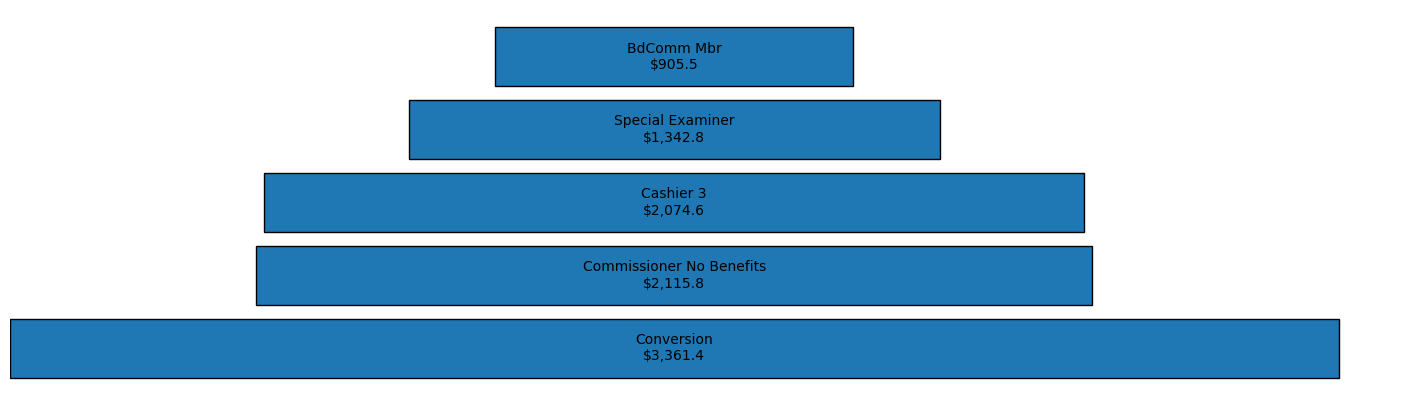

In [13]:
# 3. Which Job Title in the Year 2014 has the lowest mean salary ?

lowest_mean_job_title = data_2014_df.groupby('JobTitle',as_index=False)['TotalPayBenefits'].mean().sort_values(by='TotalPayBenefits',ascending=True).head(5).sort_values(by='TotalPayBenefits',ascending=False)

plt.figure(figsize = (18,5))
plt.barh(lowest_mean_job_title['JobTitle'],lowest_mean_job_title['TotalPayBenefits'],left=-lowest_mean_job_title['TotalPayBenefits']/2,edgecolor='black')

for i, (job_title,totalpaybenefits) in enumerate(zip(lowest_mean_job_title['JobTitle'],lowest_mean_job_title['TotalPayBenefits'])):
    plt.text(0, i, f'{job_title}\n${totalpaybenefits:,.1f}', ha='center', va='center', fontsize=10)
plt.axis('off')
plt.show()